# Scatter Plots and Initial Analysis

In [29]:
import pandas as pd
import numpy as np
from numpy.polynomial.polynomial import polyfit
import matplotlib.pyplot as plt
import seaborn as sn
import matplotlib.dates as mdates


In [3]:
db_path = "C:/Users/meita/Dropbox (MIT)/NEMSIS Data/"

## Import Data

In [4]:
nemsis = pd.read_csv(db_path + "Data/NEMSIS/Pre-processed/count_nemsis.csv")
twitter = pd.read_csv(db_path + "Data/Tweets/Pre-processed/tweet_count_w_info.csv")
wapo = pd.read_csv(db_path + "Data/WaPo/Pre-processed/fatal-police-shootings-CLEANED.csv")

# Descriptive Statistics

In [7]:
#lets get the raw wapo dataset
raw_wapo = pd.read_csv(db_path + "Data/WaPo/Raw/fatal-police-shootings-data.csv")

In [8]:
raw_wapo

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,longitude,latitude,is_geocoding_exact
0,3,Tim Elliot,2015-01-02,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False,-123.122,47.247,True
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False,-122.892,45.487,True
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False,-97.281,37.695,True
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False,-122.422,37.763,True
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False,-104.692,40.384,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6236,6803,Tory Casey,2021-04-23,shot,gun,41.0,M,B,Rosenberg,TX,False,other,NaN,False,-95.801,29.551,True
6237,6805,NaN,2021-04-23,shot,gun,NaN,M,NaN,Billings,MT,False,attack,Other,False,-108.628,45.790,True
6238,6801,Benjamin Ridley,2021-04-24,shot,gun,29.0,M,W,Webbers Falls,OK,False,other,NaN,False,-95.171,35.553,True
6239,6802,NaN,2021-04-24,shot,knife,NaN,M,NaN,Nashville,TN,False,other,Not fleeing,True,-86.831,36.194,True


In [9]:
wapo.shape

(6007, 22)

In [10]:
wapo.columns

Index(['Unnamed: 0', 'Unnamed: 0.1', 'id', 'name', 'date', 'manner_of_death',
       'armed', 'age', 'gender', 'race', 'city', 'state',
       'signs_of_mental_illness', 'threat_level', 'flee', 'body_camera',
       'longitude', 'latitude', 'is_geocoding_exact', 'cleaned_name',
       'census_division', 'geometry'],
      dtype='object')

In [11]:
#get the percent of mental health related
sum(wapo['signs_of_mental_illness'])/wapo.shape[0] * 100

23.356084568003997

In [13]:
wapo[wapo['race'] == 'B'].shape[0] / wapo.shape[0] * 100

24.887631097053436

In [14]:
wapo[wapo['race'] == 'H'].shape[0] / wapo.shape[0] * 100

17.41301814549692

In [15]:
wapo[wapo['race'] == 'W'].shape[0] / wapo.shape[0] * 100

47.8441817879141

In [19]:
#get the number of tweets as a rolling average
tweets = pd.DataFrame(twitter.groupby(['date']).sum())[['tweet_count', 'retweet_count', 'quote_count']]

In [24]:
tweets['all_retweets'] = tweets['retweet_count'] + tweets['quote_count']

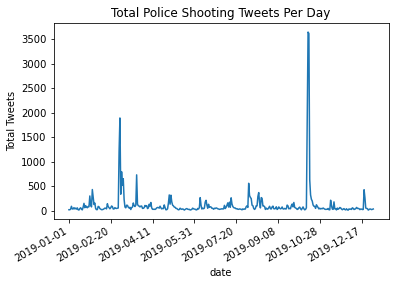

In [34]:
ax = tweets['tweet_count'].plot()

# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
# set formatter
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
# set font and rotation for date tick labels
plt.gcf().autofmt_xdate()
plt.title("Total Police Shooting Tweets Per Day")
plt.ylabel("Total Tweets")
plt.show()

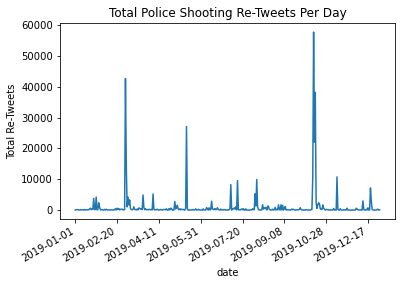

In [35]:
ax = tweets['all_retweets'].plot()

# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
# set formatter
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
# set font and rotation for date tick labels
plt.gcf().autofmt_xdate()
plt.title("Total Police Shooting Re-Tweets Per Day")
plt.ylabel("Total Re-Tweets")
plt.show()

In [36]:
tweets['tweet_count'].describe()

count     365.000000
mean      110.550685
std       314.836048
min         8.000000
25%        30.000000
50%        46.000000
75%        87.000000
max      3644.000000
Name: tweet_count, dtype: float64

In [37]:
np.median(tweets['tweet_count'])

46.0

In [38]:
tweets['all_retweets'].describe()

count      365.000000
mean      1068.912329
std       4803.396033
min          2.000000
25%         46.000000
50%        125.000000
75%        385.000000
max      57720.000000
Name: all_retweets, dtype: float64

In [39]:
np.median(tweets['all_retweets'])

125.0

In [42]:
np.quantile(tweets['tweet_count'], [.2, .4, .6, .8, 1])

array([  27. ,   38. ,   56.4,   99. , 3644. ])

In [43]:
np.quantile(tweets['all_retweets'], [.2, .4, .6, .8, 1])

array([3.880e+01, 8.160e+01, 1.964e+02, 4.784e+02, 5.772e+04])

In [44]:
by_name  = pd.DataFrame(twitter.groupby(['name']).sum())[['tweet_count', 'retweet_count', 'quote_count']]

In [45]:
by_name['all_retweets'] = by_name['retweet_count'] + by_name['quote_count']

In [52]:
sum(by_name['all_retweets'].sort_values(ascending = False)[:5])/sum(by_name['all_retweets'])*100

71.55833737021118

In [53]:
#get the share of mental health related private, urban calls
private = nemsis[nemsis['origin'] == 'private']
private_and_urban = private[private['urban'] == 'urban']

In [113]:
pu_w_psych = private_and_urban[private_and_urban['psych']].groupby(['day']).sum()['total']
pu_all = private_and_urban.groupby(['day']).sum()['total']

In [55]:
pu_share = pd.DataFrame(np.divide(pu_w_psych, pu_all))

In [56]:
pu_share.describe()

,total
count,365.000000
mean,0.031946
std,0.001464
min,0.026736
25%,0.030967
50%,0.031936
75%,0.032934
max,0.036248


# Add the day of the week and de-mean

In [59]:
nemsis.columns

Index(['day', 'CensusDivision', 'urban', 'origin', 'psych', 'total'], dtype='object')

In [61]:
nemsis['date'] = pd.to_datetime(nemsis['day'])

In [62]:
nemsis['day_of_week'] = nemsis['date'].dt.strftime('%A')

In [67]:
all_psych = nemsis[nemsis['psych']]

In [71]:
all_psych_by_day = pd.DataFrame(all_psych.groupby(['day_of_week']).sum()['total'])

In [75]:
all_psych_by_day.rename(columns = {'total':'psych_total'}, inplace = True)

In [73]:
all_by_day = pd.DataFrame(nemsis.groupby(['day_of_week']).sum()['total'])

In [77]:
by_day = all_by_day.merge(all_psych_by_day, left_index = True, right_index = True)

In [79]:
by_day['perc'] = by_day['psych_total']/by_day['total'] * 100

In [91]:
by_day = by_day.reindex(['Monday','Tuesday', 'Wednesday', 'Thursday', 'Friday','Saturday', 'Sunday'])
by_day

,total,psych_total,perc
day_of_week,,,
Monday,3867468,120257,3.109450
Tuesday,3843062,121259,3.155270
Wednesday,3780781,118871,3.144086
Thursday,3800875,117132,3.081711
Friday,3929529,116818,2.972824
Saturday,3715045,105657,2.844030
Sunday,3541260,107174,3.026437


Text(0.5, 1.0, 'Percentage of Mental Health Related Calls by Day')

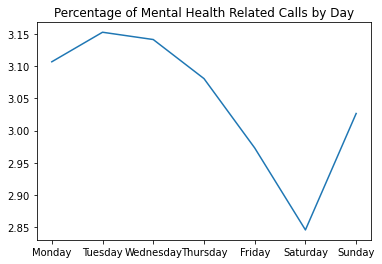

In [111]:
plt.plot(by_day_02['perc'])
plt.title("Percentage of Mental Health Related Calls by Day")

In [92]:
all_by_date = pd.DataFrame(nemsis.groupby(['date']).sum()['total'])

In [99]:
psych_by_date = pd.DataFrame(nemsis[nemsis['psych']].groupby(['date']).sum()['total'])

In [96]:
all_by_date['day_of_the_week'] = all_by_date.index.strftime('%A')

In [100]:
psych_by_date.rename(columns = {'total':'psych_total'}, inplace = True)

In [101]:
all_w_date = all_by_date.merge(psych_by_date, left_index = True, right_index = True)

In [103]:
all_w_date['perc'] = all_w_date['psych_total']/all_w_date['total'] * 100

In [107]:
by_day_02 = pd.DataFrame(all_w_date.groupby(['day_of_the_week']).mean()['perc'])

In [109]:
by_day_02 = by_day_02.reindex(['Monday','Tuesday', 'Wednesday', 'Thursday', 'Friday','Saturday', 'Sunday'])
by_day_02

,perc
day_of_the_week,
Monday,3.107135
Tuesday,3.153099
Wednesday,3.141761
Thursday,3.080971
Friday,2.973040
Saturday,2.845492
Sunday,3.026666


In [110]:
by_day

,total,psych_total,perc
day_of_week,,,
Monday,3867468,120257,3.109450
Tuesday,3843062,121259,3.155270
Wednesday,3780781,118871,3.144086
Thursday,3800875,117132,3.081711
Friday,3929529,116818,2.972824
Saturday,3715045,105657,2.844030
Sunday,3541260,107174,3.026437


In [112]:
def de_mean(row):
    day = row['day_of_the_week']
    mean = by_day_02.iloc[day]['perc']
    return row['perc'] - mean

In [119]:
pu_df = pd.DataFrame(pu_w_psych).rename(columns = {'total':'psych_total'})

In [121]:
pu_all = pd.DataFrame(pu_all)

In [125]:
pu_df = pu_df.join(pu_all)

In [129]:
pu_df['date'] = pd.to_datetime(pu_df.index)

In [131]:
pu_df['day_of_the_week'] = pu_df.date.dt.strftime('%A')

In [133]:
pu_df['perc'] = pu_df['psych_total'] / pu_df['total'] * 100

In [136]:
pu_by_day = pd.DataFrame(pu_df.groupby(['day_of_the_week']).mean()['perc']).reindex(['Monday','Tuesday', 'Wednesday', 'Thursday', 'Friday','Saturday', 'Sunday'])

Text(0.5, 1.0, 'Percentage of Mental Health Related Calls From Private Residences in Urban Areas by Day')

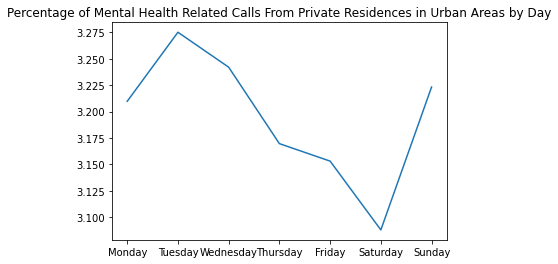

In [138]:
plt.plot(pu_by_day['perc'])
plt.title("Percentage of Mental Health Related Calls From Private Residences in Urban Areas by Day")

In [139]:
pu_by_day

,perc
day_of_the_week,
Monday,3.209729
Tuesday,3.275090
Wednesday,3.242029
Thursday,3.169685
Friday,3.153127
Saturday,3.088018
Sunday,3.223241


# Rolling Average

## Filter Data of Interest

In [7]:
pu_share

,total
day,
2019-01-01,0.032340
2019-01-02,0.032772
2019-01-03,0.031312
2019-01-04,0.032894
2019-01-05,0.031446
...,...
2019-12-27,0.031335
2019-12-28,0.030715
2019-12-29,0.030934


In [8]:
#get the 7 day rolling average
pu_share['Rolling'] = pu_share['total'].rolling(7).mean()

In [9]:
pu_share

,total,Rolling
day,,
2019-01-01,0.032340,NaN
2019-01-02,0.032772,NaN
2019-01-03,0.031312,NaN
2019-01-04,0.032894,NaN
2019-01-05,0.031446,NaN
...,...,...
2019-12-27,0.031335,0.029645
2019-12-28,0.030715,0.029649
2019-12-29,0.030934,0.029696


In [10]:
#get the share of mental health related private, street and public calls
sp = nemsis[nemsis['origin'].isin(['public', 'street'])]
sp_urban = sp[sp['urban'] == 'urban']
sp_psych = sp_urban[sp_urban['psych']].groupby(['day']).sum()['total']
sp_all = sp_urban.groupby(['day']).sum()['total']
sp_share = pd.DataFrame(np.divide(sp_psych, sp_all))
#get the 7 day rolling average
sp_share['Rolling'] = sp_share['total'].rolling(7).mean()

In [11]:
sp_share

,total,Rolling
day,,
2019-01-01,0.028710,NaN
2019-01-02,0.030421,NaN
2019-01-03,0.029114,NaN
2019-01-04,0.025197,NaN
2019-01-05,0.030448,NaN
...,...,...
2019-12-27,0.037887,0.030696
2019-12-28,0.029609,0.030404
2019-12-29,0.031072,0.031545


In [16]:
wapo['day'] = pd.to_datetime(wapo['date'])

In [17]:
#number of police killings rolling 7 day average
wapo_2019 = wapo[wapo['day'].dt.year == 2019]

In [18]:
wapo_2019.shape[0]

947

In [14]:
wapo_by_day = pd.DataFrame(wapo_2019.groupby(['day']).size()).rename(columns = {0:'count'}).reset_index()

In [15]:
wapo_by_day

,day,count
0,2019-01-01,2
1,2019-01-02,3
2,2019-01-03,6
3,2019-01-04,4
4,2019-01-05,5
...,...,...
324,2019-12-27,4
325,2019-12-28,5
326,2019-12-29,4
327,2019-12-30,2


In [16]:
wapo_all_days = pd.DataFrame(sp_share.index, columns = ['day'])

In [17]:
wapo_all_days['date'] = pd.to_datetime(wapo_all_days['day'])

In [18]:
wapo_by_day['date'] = pd.to_datetime(wapo_by_day['day'])

In [19]:
wapo_all = wapo_all_days.merge(wapo_by_day, how = 'outer', on = 'date')

In [20]:
wapo_all.drop(columns = ['day_x', 'day_y'])

,date,count
0,2019-01-01,2.0
1,2019-01-02,3.0
2,2019-01-03,6.0
3,2019-01-04,4.0
4,2019-01-05,5.0
...,...,...
360,2019-12-27,4.0
361,2019-12-28,5.0
362,2019-12-29,4.0
363,2019-12-30,2.0


In [21]:
wapo_all['Rolling'] = wapo_all['count'].rolling(7).sum()

In [23]:
tweets['tweet_avg'] = tweets['tweet_count'].rolling(7).mean()
tweets['retweet_avg'] = (tweets['retweet_count'] + tweets['quote_count']).rolling(7).mean()

In [24]:
tweets

,tweet_count,retweet_count,quote_count,tweet_avg,retweet_avg
date,,,,,
2019-01-01,16,21,1,NaN,NaN
2019-01-02,15,90,3,NaN,NaN
2019-01-03,27,135,61,NaN,NaN
2019-01-04,86,110,17,NaN,NaN
2019-01-05,33,40,8,NaN,NaN
...,...,...,...,...,...
2019-12-27,32,15,0,65.142857,484.714286
2019-12-28,27,202,31,31.428571,83.285714
2019-12-29,18,281,4,26.857143,94.857143


# Create Scatter Plots and Best Fit Lines

Text(0, 0.5, 'Share of Mental Health Related Urban/Private Calls')

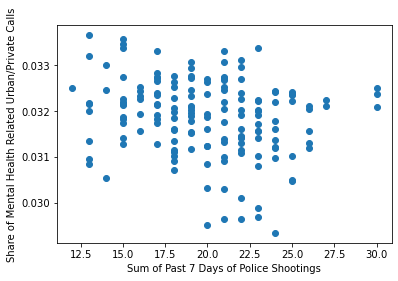

In [26]:
'''
x: number of police killings (7 day rolling sum)
y: share of urban private calls (7 day rolling average)
'''
x = wapo_all['Rolling']
y = pu_share['Rolling']
plt.scatter(x, y)
plt.xlabel('Sum of Past 7 Days of Police Shootings')
plt.ylabel('Share of Mental Health Related Urban/Private Calls')
# plt.plot(x, np.poly1d(np.polyfit(x, y, 1))(x))
# plt.show()

Text(0, 0.5, 'Share of Mental Health Related Urban/Private Calls')

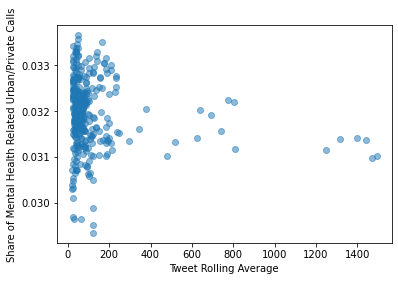

In [29]:
'''
x: tweet average (7 day rolling average)
y: share of urban private calls (7 day rolling average)
'''
x = tweets['tweet_avg']
y = pu_share['Rolling']
plt.scatter(x, y, alpha = .5)
plt.xlabel('Tweet Rolling Average')
plt.ylabel('Share of Mental Health Related Urban/Private Calls')
# plt.plot(x, np.poly1d(np.polyfit(x, y, 1))(x))
# plt.show()

Text(0, 0.5, 'Share of Mental Health Related Urban/Private Calls')

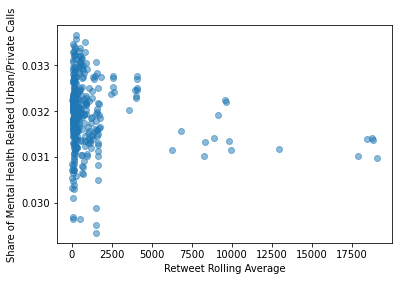

In [31]:
'''
x: retweet  average (7 day rolling average)
y: share of urban private calls (7 day rolling average)
'''
x = tweets['retweet_avg']
y = pu_share['Rolling']
plt.scatter(x, y, alpha = .5)
plt.xlabel('Retweet Rolling Average')
plt.ylabel('Share of Mental Health Related Urban/Private Calls')
# plt.plot(x, np.poly1d(np.polyfit(x, y, 1))(x))
# plt.show()

Text(0, 0.5, 'Share of Mental Health Related Street/Public Calls')

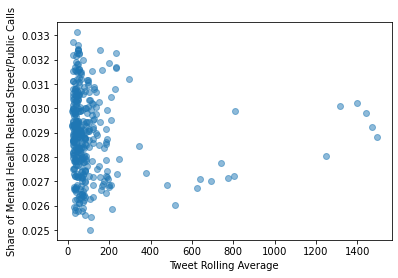

In [33]:
'''
x: tweet average (7 day rolling average)
y: share of urban street/public calls (7 day rolling average)
'''
x = tweets['tweet_avg']
y = sp_share['Rolling']
plt.scatter(x, y, alpha= .5)
plt.xlabel('Tweet Rolling Average')
plt.ylabel('Share of Mental Health Related Street/Public Calls')
# plt.plot(x, np.poly1d(np.polyfit(x, y, 1))(x))
# plt.show()

Text(0, 0.5, 'Share of Mental Health Related Street/Public Calls')

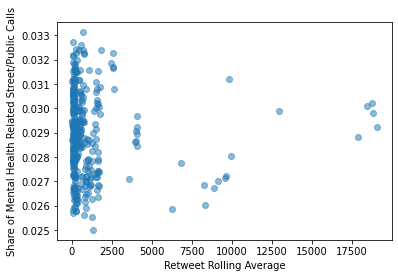

In [35]:
'''
x: tweet average (7 day rolling average)
y: share of urban street/public calls (7 day rolling average)
'''
x = tweets['retweet_avg']
y = sp_share['Rolling']
plt.scatter(x, y, alpha = .5)
plt.xlabel('Retweet Rolling Average')
plt.ylabel('Share of Mental Health Related Street/Public Calls')
# plt.plot(x, np.poly1d(np.polyfit(x, y, 1))(x))
# plt.show()

# Graphs for Each Census Division

In [40]:
divs = np.unique(nemsis['CensusDivision'])
divs

array(['East North Central', 'East South Central', 'Middle Atlantic',
       'Mountain', 'New England', 'Pacific', 'South Atlantic',
       'West North Central', 'West South Central'], dtype=object)

In [51]:
def get_all_days(og_df):
    all_days = pd.DataFrame(sp_share.index, columns = ['day'])
    all_days['date'] = pd.to_datetime(all_days['day'])
    og_df['date'] = pd.to_datetime(og_df['date'])
    df_all = all_days.merge(og_df, how = 'outer', on = 'date')
    return df_all.drop(columns = ['day'])

<ipython-input-51-1ebeb31ff980>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  og_df['date'] = pd.to_datetime(og_df['date'])


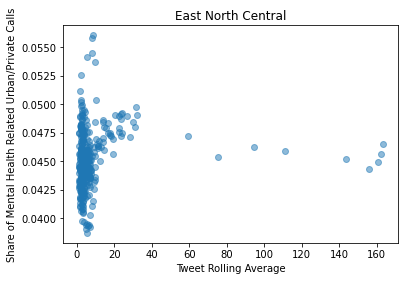

LinAlgError: SVD did not converge in Linear Least Squares

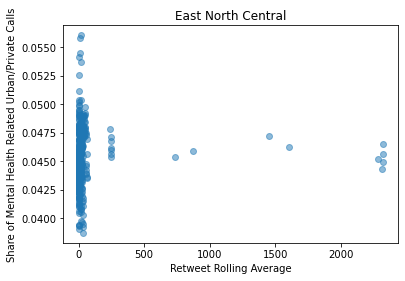

In [72]:
#do the urban private ones
for d in divs:
    dprivate_and_urban = private_and_urban[private_and_urban['CensusDivision'] == d]
    pu_w_psych = dprivate_and_urban[dprivate_and_urban['psych']].groupby(['day']).sum()['total']
    pu_all = dprivate_and_urban.groupby(['day']).sum()['total']
    pu_share = pd.DataFrame(np.divide(pu_w_psych, pu_all))
    pu_share['Rolling'] = pu_share['total'].rolling(7).mean()
    
    #get the share of mental health related private, street and public calls

    dsp_urban = sp_urban[sp_urban['CensusDivision'] == d]
    sp_psych = dsp_urban[dsp_urban['psych']].groupby(['day']).sum()['total']
    sp_all = dsp_urban.groupby(['day']).sum()['total']
    sp_share = pd.DataFrame(np.divide(sp_psych, sp_all))
    
    #get the 7 day rolling average
    sp_share['Rolling'] = sp_share['total'].rolling(7).mean()
    
    dtwitter = twitter[twitter['census_division'] == d]
    dtwitter = get_all_days(dtwitter)
    tweets = pd.DataFrame(dtwitter.groupby(['date']).sum())[['tweet_count', 'retweet_count', 'quote_count']]
    tweets['tweet_avg'] = tweets['tweet_count'].rolling(7).mean()
    tweets['retweet_avg'] = (tweets['retweet_count'] + tweets['quote_count']).rolling(7).mean()
    
    
    '''
    x: tweet average (7 day rolling average)
    y: share of urban private calls (7 day rolling average)
    '''
    x = tweets['tweet_avg']
#     print(x.shape)
    y = pu_share['Rolling']
#     print(y.shape)
    plt.scatter(x, y, alpha = .5)
    plt.xlabel('Tweet Rolling Average')
    plt.ylabel('Share of Mental Health Related Urban/Private Calls')
    plt.title(d)
    try:
        plt.plot(x, np.poly1d(np.polyfit(x, y, 1))(x))
    except:
        pass
    plt.show()
    
    '''
    x: retweet  average (7 day rolling average)
    y: share of urban private calls (7 day rolling average)
    '''
    x = tweets['retweet_avg']
    y = pu_share['Rolling']
    plt.scatter(x, y, alpha = .5)
    plt.title(d)
    plt.xlabel('Retweet Rolling Average')
    plt.ylabel('Share of Mental Health Related Urban/Private Calls')
    try:
        plt.plot(x, np.poly1d(np.polyfit(x, y, 1))(x))
    except:
        pass
    plt.show()


<ipython-input-51-1ebeb31ff980>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  og_df['date'] = pd.to_datetime(og_df['date'])


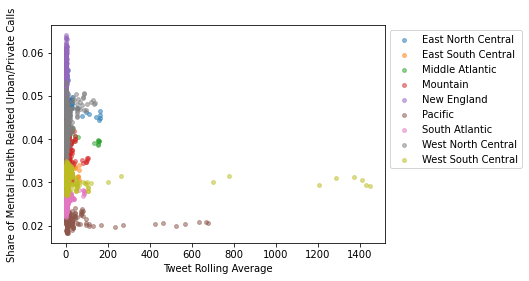

In [70]:
#do the urban private ones
for d in divs:
    dprivate_and_urban = private_and_urban[private_and_urban['CensusDivision'] == d]
    pu_w_psych = dprivate_and_urban[dprivate_and_urban['psych']].groupby(['day']).sum()['total']
    pu_all = dprivate_and_urban.groupby(['day']).sum()['total']
    pu_share = pd.DataFrame(np.divide(pu_w_psych, pu_all))
    pu_share['Rolling'] = pu_share['total'].rolling(7).mean()
    
    #get the share of mental health related private, street and public calls

    dsp_urban = sp_urban[sp_urban['CensusDivision'] == d]
    sp_psych = dsp_urban[dsp_urban['psych']].groupby(['day']).sum()['total']
    sp_all = dsp_urban.groupby(['day']).sum()['total']
    sp_share = pd.DataFrame(np.divide(sp_psych, sp_all))
    
    #get the 7 day rolling average
    sp_share['Rolling'] = sp_share['total'].rolling(7).mean()
    
    dtwitter = twitter[twitter['census_division'] == d]
    dtwitter = get_all_days(dtwitter)
    tweets = pd.DataFrame(dtwitter.groupby(['date']).sum())[['tweet_count', 'retweet_count', 'quote_count']]
    tweets['tweet_avg'] = tweets['tweet_count'].rolling(7).mean()
    tweets['retweet_avg'] = (tweets['retweet_count'] + tweets['quote_count']).rolling(7).mean()
    
    
    '''
    x: tweet average (7 day rolling average)
    y: share of urban private calls (7 day rolling average)
    '''
    x = tweets['tweet_avg']
#     print(x.shape)
    y = pu_share['Rolling']
#     print(y.shape)
    plt.scatter(x, y, alpha = .5, s = 15, label = d)
plt.legend(bbox_to_anchor=(1,1), loc="upper left")
plt.xlabel('Tweet Rolling Average')
plt.ylabel('Share of Mental Health Related Urban/Private Calls')
plt.show()



In [ ]:
    '''
    x: retweet  average (7 day rolling average)
    y: share of urban private calls (7 day rolling average)
    '''
    x = tweets['retweet_avg']
    y = pu_share['Rolling']
    plt.scatter(x, y, alpha = .5)
    plt.title(d)
    plt.xlabel('Retweet Rolling Average')
    plt.ylabel('Share of Mental Health Related Urban/Private Calls')
    try:
        plt.plot(x, np.poly1d(np.polyfit(x, y, 1))(x))
    except:
        pass
    plt.show()


In [ ]:
plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)))

# Sample data
x = np.arange(10)
y = 5 * x + 10

# Fit with polyfit
b, m = polyfit(x, y, 1)

plt.plot(x, y, '.')
plt.plot(x, b + m * x, '-')
plt.show()